In [3]:
import numpy as np
import pandas as pd

PATH = r"C:\DATA\diabetes.csv"

df = pd.read_csv(PATH)

In [4]:
df[
    [
        "Glucose",
        "BloodPressure",
        "SkinThickness",
        "Insulin",
        "BMI",
        "DiabetesPedigreeFunction",
        "Age",
    ]
] = df[
    [
        "Glucose",
        "BloodPressure",
        "SkinThickness",
        "Insulin",
        "BMI",
        "DiabetesPedigreeFunction",
        "Age",
    ]
].replace(0, np.nan)

df.fillna(df.mean(), inplace=True)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148.0,72.0,35.00000,155.548223,33.6,0.627,50,1
1,1,85.0,66.0,29.00000,155.548223,26.6,0.351,31,0
2,8,183.0,64.0,29.15342,155.548223,23.3,0.672,32,1
3,1,89.0,66.0,23.00000,94.000000,28.1,0.167,21,0
4,0,137.0,40.0,35.00000,168.000000,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101.0,76.0,48.00000,180.000000,32.9,0.171,63,0
764,2,122.0,70.0,27.00000,155.548223,36.8,0.340,27,0
765,5,121.0,72.0,23.00000,112.000000,26.2,0.245,30,0
766,1,126.0,60.0,29.15342,155.548223,30.1,0.349,47,1


In [6]:
corr = df.corr()
print(corr)

                          Pregnancies   Glucose  BloodPressure  SkinThickness  \
Pregnancies                  1.000000  0.127911       0.208522       0.082989   
Glucose                      0.127911  1.000000       0.218367       0.192991   
BloodPressure                0.208522  0.218367       1.000000       0.192816   
SkinThickness                0.082989  0.192991       0.192816       1.000000   
Insulin                      0.056027  0.420157       0.072517       0.158139   
BMI                          0.021565  0.230941       0.281268       0.542398   
DiabetesPedigreeFunction    -0.033523  0.137060      -0.002763       0.100966   
Age                          0.544341  0.266534       0.324595       0.127872   
Outcome                      0.221898  0.492928       0.166074       0.215299   

                           Insulin       BMI  DiabetesPedigreeFunction  \
Pregnancies               0.056027  0.021565                 -0.033523   
Glucose                   0.420157  0.230

In [9]:
df.shape

(768, 9)

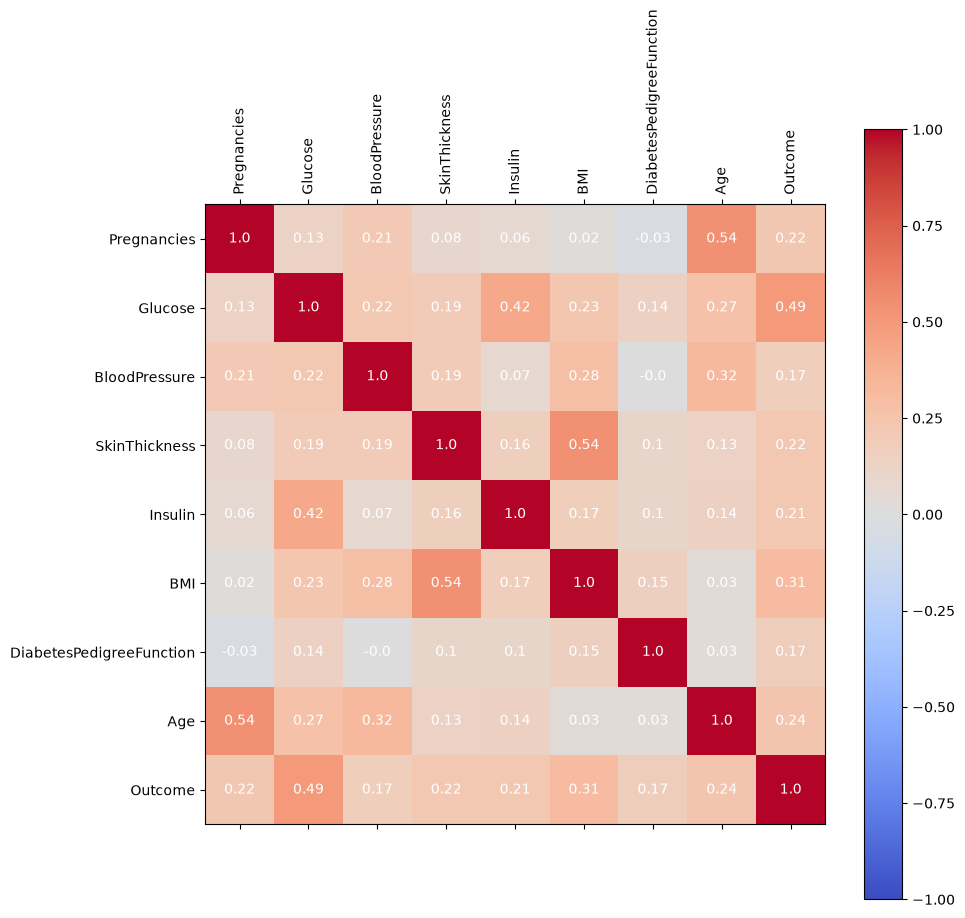

In [8]:
%matplotlib inline
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 10))
cax     = ax.matshow(corr,cmap='coolwarm', vmin=-1, vmax=1)
fig.colorbar(cax)
ticks = np.arange(0,len(df.columns),1)
ax.set_xticks(ticks)
ax.set_xticklabels(df.columns)
plt.xticks(rotation = 90)

ax.set_yticks(ticks)
ax.set_yticklabels(df.columns)

#---print the correlation factor--
for i in range(df.shape[1]):
    for j in range(9):
        text = ax.text(j, i, round(corr.iloc[i, j],2),
                       ha="center", va="center", color="w")
plt.show()

In [1]:
import json

import requests


def predict_diabetes(BMI, Age, Glucose):

    url = "http://127.0.0.1:5000/diabetes/v1/predict"

    data = {"BMI": BMI, "Age": Age, "Glucose": Glucose}

    data_json = json.dumps(data)

    headers = {"Content-type": "application/json"}

    response = requests.post(url, data=data_json, headers=headers)

    result = json.loads(response.text)

    return result

In [2]:
if __name__ == "__main__":
    BMI = float(input("BMI?"))
    Age = float(input("Age?"))
    Glucose = float(input("Glucose?"))

    predictions = predict_diabetes(BMI, Age, Glucose)

    print("Diabetic" if predictions["prediction"] == 1 else "Not Diabetic")

    print("Confidence: " + predictions["confidence"] + "%")


Not Diabetic
Confidence: 52.63%
